# PPO Experiments

Clip vs no-clip on **LunarLander-v3** with mini-batch updates.

Fig 2 uses **env steps** (not episodes) on the x-axis so the two curves share a fair common baseline:
both methods run exactly `N_ROLLOUTS × ROLLOUT_STEPS` steps.

**Figures exported:**
- `fig1_noclip_instability.pdf` — 5 seeds of no-clip PPO (raw + smoothed mean, x = episode)
- `fig2_clip_vs_noclip.pdf`    — clip vs no-clip, mean ± std, x = env steps (×10³)
- `fig3_policy_ratio.pdf`      — mean r_t per epoch (before each epoch's mini-batch updates)

In [70]:
try:
    import gymnasium as gym
    _GYM_MAKE = gym.make
except ImportError:
    import gym
    _GYM_MAKE = gym.make

In [71]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

BLUE  = '#2166AC'
RED   = '#D6604D'
GRAY  = '#808080'
FIGSIZE = (7.2, 4.8)
OUTDIR  = '.'

In [72]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
ENV_ID        = 'LunarLander-v3'
N_SEEDS       = 5
N_ROLLOUTS    = 300
ROLLOUT_STEPS = 2048
K_EPOCHS      = 20
BATCH_SIZE    = 64
GAMMA         = 0.99
GAE_LAMBDA    = 0.95
LR            = 3e-4
CLIP_EPS      = 0.2
ENT_COEF      = 0.01
VF_COEF       = 0.5
MAX_GRAD_NORM = 0.5
HIDDEN_SIZE   = 64
SMOOTH_WIN    = 20
SEED_BASE     = 42

TOTAL_STEPS   = N_ROLLOUTS * ROLLOUT_STEPS   # 614 400
STEP_GRID     = np.linspace(0, TOTAL_STEPS, 500)  # common x-axis for Fig 2

In [73]:
def style_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

def smooth(x, w):
    x = np.array(x, dtype=float)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w) / w, mode='valid')

def plot_mean_std(ax, data, color, label, smooth_win=1):
    """Episode-indexed mean ± std (for Fig 1)."""
    if smooth_win > 1:
        data = [smooth(row, smooth_win) for row in data]
    min_len = min(len(r) for r in data)
    arr = np.array([r[:min_len] for r in data])
    mu, std = arr.mean(0), arr.std(0)
    ax.plot(mu, color=color, linewidth=1.5, label=label)
    ax.fill_between(np.arange(min_len), mu - std, mu + std, color=color, alpha=0.15)

def plot_mean_std_steps(ax, ep_steps_list, ep_returns_list, color, label, smooth_win=1):
    """Step-indexed mean ± std on STEP_GRID (for Fig 2)."""
    curves = []
    for ep_steps, ep_returns in zip(ep_steps_list, ep_returns_list):
        s = np.array(ep_steps,   dtype=float)
        r = np.array(ep_returns, dtype=float)
        if smooth_win > 1 and len(r) >= smooth_win:
            r = smooth(r, smooth_win)
            s = s[smooth_win - 1:]       # align: smooth output index i → episode i+w-1
        # Forward-fill onto the common step grid
        curve = np.interp(STEP_GRID, s, r, left=r[0])
        curves.append(curve)
    arr = np.array(curves)
    mu, std = arr.mean(0), arr.std(0)
    xs = STEP_GRID / 1e3                 # display in thousands
    ax.plot(xs, mu, color=color, linewidth=1.5, label=label)
    ax.fill_between(xs, mu - std, mu + std, color=color, alpha=0.15)

In [74]:
class ActorCritic(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=HIDDEN_SIZE):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),  nn.Tanh(),
        )
        self.actor  = nn.Linear(hidden, n_actions)
        self.critic = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.shared(x)
        return self.actor(h), self.critic(h).squeeze(-1)

    def act(self, obs):
        logits, value = self(obs)
        dist = Categorical(logits=logits)
        a    = dist.sample()
        return a, dist.log_prob(a), value

    def evaluate(self, obs, actions):
        logits, values = self(obs)
        dist = Categorical(logits=logits)
        return dist.log_prob(actions), values, dist.entropy()

In [75]:
def compute_gae(rewards, values, dones, last_value=0.0, gamma=GAMMA, lam=GAE_LAMBDA):
    advantages, gae, nv = [], 0.0, last_value
    for r, v, d in zip(reversed(rewards), reversed(values), reversed(dones)):
        delta = r + gamma * nv * (1 - d) - v
        gae   = delta + gamma * lam * (1 - d) * gae
        advantages.insert(0, gae)
        nv = v
    returns = [a + v for a, v in zip(advantages, values)]
    return advantages, returns


def collect_rollout(env, policy, device, step_offset):
    """step_offset: total env steps completed before this rollout."""
    bufs = {k: [] for k in ('obs', 'act', 'logp', 'val', 'rew', 'done')}
    obs, _ = env.reset()
    ep_returns, ep_step_ends = [], []   # ep_step_ends: global step when episode finished
    ep_ret, done = 0.0, False

    for local_step in range(ROLLOUT_STEPS):
        obs_t = torch.FloatTensor(obs).to(device)
        with torch.no_grad():
            a, logp, val = policy.act(obs_t)
        next_obs, rew, term, trunc, _ = env.step(a.item())
        done = term or trunc

        bufs['obs'].append(obs);         bufs['act'].append(a.item())
        bufs['logp'].append(logp.item()); bufs['val'].append(val.item())
        bufs['rew'].append(rew);         bufs['done'].append(float(done))

        ep_ret += rew
        if done:
            ep_returns.append(ep_ret)
            ep_step_ends.append(step_offset + local_step + 1)  # 1-indexed global step
            ep_ret = 0.0
            obs, _ = env.reset()
        else:
            obs = next_obs

    if done:
        last_value = 0.0
    else:
        with torch.no_grad():
            _, last_value = policy(torch.FloatTensor(obs).to(device))
            last_value = last_value.item()

    return bufs, ep_returns, ep_step_ends, last_value


def update_policy(policy, optimizer, bufs, last_value, device, use_clip):
    advs, rets = compute_gae(bufs['rew'], bufs['val'], bufs['done'], last_value)
    advs = np.array(advs, dtype=np.float32)
    advs = (advs - advs.mean()) / (advs.std() + 1e-8)

    N = len(bufs['obs'])
    obs_t    = torch.FloatTensor(bufs['obs']).to(device)
    act_t    = torch.LongTensor(bufs['act']).to(device)
    ret_t    = torch.FloatTensor(rets).to(device)
    adv_t    = torch.FloatTensor(advs).to(device)
    logp_old = torch.FloatTensor(bufs['logp']).to(device)

    epoch_ratios = []
    for _ in range(K_EPOCHS):
        with torch.no_grad():
            logp_now, _, _ = policy.evaluate(obs_t, act_t)
            epoch_ratios.append(torch.exp(logp_now - logp_old).mean().item())

        perm = torch.randperm(N, device=device)
        for start in range(0, N, BATCH_SIZE):
            idx = perm[start:start + BATCH_SIZE]
            logp, vals, ent = policy.evaluate(obs_t[idx], act_t[idx])
            ratio = torch.exp(logp - logp_old[idx])

            if use_clip:
                s1 = ratio * adv_t[idx]
                s2 = torch.clamp(ratio, 1 - CLIP_EPS, 1 + CLIP_EPS) * adv_t[idx]
                actor_loss = -torch.min(s1, s2).mean()
            else:
                actor_loss = -(ratio * adv_t[idx]).mean()

            loss = actor_loss + VF_COEF * (ret_t[idx] - vals).pow(2).mean() - ENT_COEF * ent.mean()
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(policy.parameters(), MAX_GRAD_NORM)
            optimizer.step()

    return epoch_ratios

In [76]:
def run_experiment(seed, use_clip):
    torch.manual_seed(seed)
    np.random.seed(seed)
    device = torch.device('cpu')

    env       = _GYM_MAKE(ENV_ID)
    policy    = ActorCritic(env.observation_space.shape[0], env.action_space.n).to(device)
    optimizer = optim.Adam(policy.parameters(), lr=LR)

    all_ep_returns, all_ep_steps, all_ratios = [], [], []
    total_steps = 0
    for _ in range(N_ROLLOUTS):
        bufs, ep_returns, ep_step_ends, last_value = collect_rollout(
            env, policy, device, total_steps
        )
        ratios = update_policy(policy, optimizer, bufs, last_value, device, use_clip)
        all_ep_returns.extend(ep_returns)
        all_ep_steps.extend(ep_step_ends)
        all_ratios.extend(ratios)
        total_steps += ROLLOUT_STEPS

    env.close()
    return all_ep_returns, all_ep_steps, all_ratios


print('Running LunarLander-v3 experiments — est. 30–60 min ...')
noclip_returns, noclip_ep_steps, noclip_ratios = [], [], []
clip_returns,   clip_ep_steps,   clip_ratios   = [], [], []

for s in range(N_SEEDS):
    seed = SEED_BASE + s
    print(f'  seed {seed}: no-clip ...', end=' ', flush=True)
    r, st, rat = run_experiment(seed, use_clip=False)
    noclip_returns.append(r); noclip_ep_steps.append(st); noclip_ratios.append(rat)
    print('clip ...', end=' ', flush=True)
    r, st, rat = run_experiment(seed, use_clip=True)
    clip_returns.append(r);   clip_ep_steps.append(st);   clip_ratios.append(rat)
    print('done')

print('All done.')

Running LunarLander-v3 experiments — est. 30–60 min ...
  seed 42: no-clip ... clip ... done
  seed 43: no-clip ... clip ... done
  seed 44: no-clip ... clip ... done
  seed 45: no-clip ... clip ... done
  seed 46: no-clip ... clip ... done
All done.


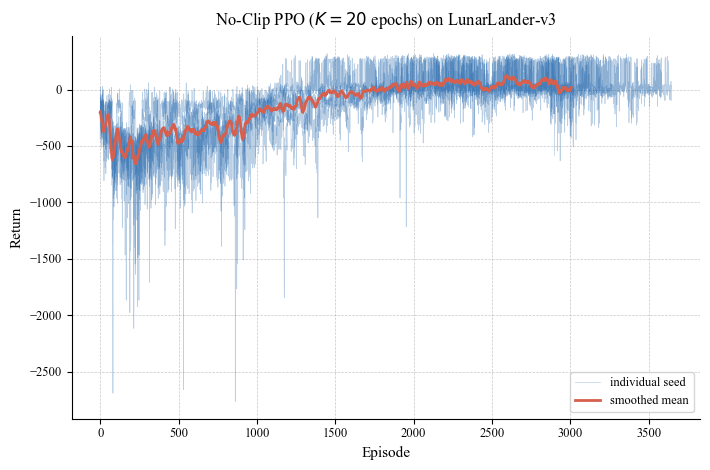

Saved fig1_noclip_instability.pdf


In [80]:
# ── Fig 1: No-Clip PPO — raw seeds + smoothed mean (x = episode) ────────────
fig, ax = plt.subplots(figsize=FIGSIZE)

for i, ret in enumerate(noclip_returns):
    ax.plot(ret, color=BLUE, linewidth=0.5, alpha=0.3,
            label='individual seed' if i == 0 else None)

min_len = min(len(r) for r in noclip_returns)
mat     = np.array([r[:min_len] for r in noclip_returns])
ax.plot(smooth(mat.mean(0), SMOOTH_WIN), color=RED, linewidth=2.0, label='smoothed mean')

style_axes(ax)
ax.set_xlabel('Episode')
ax.set_ylabel('Return')
ax.set_title('No-Clip PPO ($K=20$ epochs) on LunarLander-v3', pad=8)
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(f'{OUTDIR}/fig1_noclip_instability.pdf', bbox_inches='tight')
plt.show()
print('Saved fig1_noclip_instability.pdf')

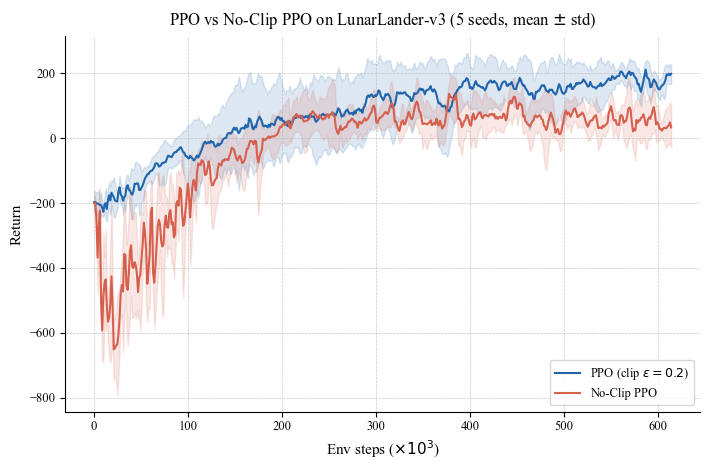

Saved fig2_clip_vs_noclip.pdf


In [78]:
# ── Fig 2: Clip vs No-Clip  (x = env steps ×10³, fair comparison) ───────────
fig, ax = plt.subplots(figsize=FIGSIZE)

plot_mean_std_steps(ax, clip_ep_steps,   clip_returns,   BLUE, 'PPO (clip $\\epsilon=0.2$)', SMOOTH_WIN)
plot_mean_std_steps(ax, noclip_ep_steps, noclip_returns, RED,  'No-Clip PPO',                SMOOTH_WIN)

style_axes(ax)
ax.set_xlabel('Env steps ($\\times 10^3$)')
ax.set_ylabel('Return')
ax.set_title('PPO vs No-Clip PPO on LunarLander-v3 (5 seeds, mean $\\pm$ std)', pad=8)
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(f'{OUTDIR}/fig2_clip_vs_noclip.pdf', bbox_inches='tight')
plt.show()
print('Saved fig2_clip_vs_noclip.pdf')

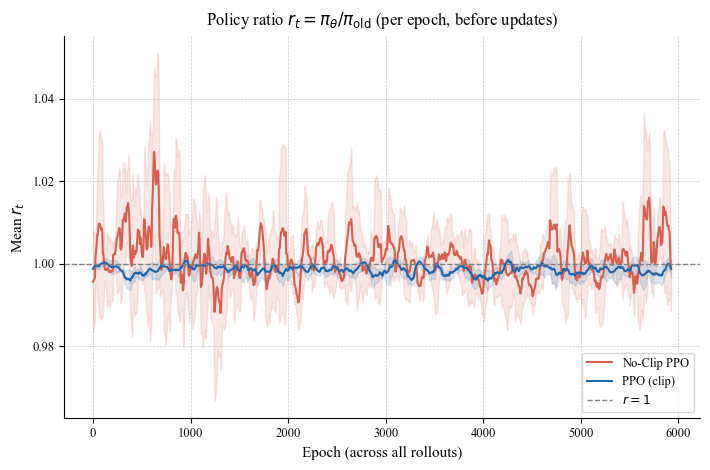

Saved fig3_policy_ratio.pdf


In [79]:
# ── Fig 3: Policy ratio per epoch ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=FIGSIZE)

sw = max(1, N_ROLLOUTS * K_EPOCHS // 80)
plot_mean_std(ax, noclip_ratios, RED,  'No-Clip PPO', smooth_win=sw)
plot_mean_std(ax, clip_ratios,   BLUE, 'PPO (clip)',   smooth_win=sw)
ax.axhline(1.0, color=GRAY, linewidth=1.0, linestyle='--', label='$r=1$')

style_axes(ax)
ax.set_xlabel('Epoch (across all rollouts)')
ax.set_ylabel('Mean $r_t$')
ax.set_title('Policy ratio $r_t = \\pi_\\theta / \\pi_\\mathrm{old}$ (per epoch, before updates)', pad=8)
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(f'{OUTDIR}/fig3_policy_ratio.pdf', bbox_inches='tight')
plt.show()
print('Saved fig3_policy_ratio.pdf')